# Thermal Comfort Predictor — Model Training Notebook
**Project:** Minor Project Sem 6  
**Dataset:** India Thermal Comfort Data (`india_data_cleaned.csv`)  
**Model:** XGBoost Classifier  
**Target:** Thermal Sensation Vote (TSV) — Classes: -3 (Cold) to +3 (Hot)  

---
### Notebook Flow
1. Import Libraries
2. Load & Explore Dataset
3. Feature Engineering (add `tr` column)
4. Train / Test Split
5. Feature Scaling
6. Train XGBoost Model
7. Evaluate — Accuracy, Classification Report, Confusion Matrix
8. Feature Importance Plot
9. Save Model & Scaler as `.pkl`

---
## Step 1 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load & Explore Dataset

In [6]:
# Load the cleaned India dataset
df = pd.read_csv('india_data_cleaned.csv')

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (15191, 6)

Column Names: ['ta', 'rh', 'v', 'met', 'clo', 'thermal_sensation']

First 5 rows:


,ta,rh,v,met,clo,thermal_sensation
0,25.2,64.0,0.10,1.0,0.75,-2
1,28.1,56.7,0.09,1.2,0.53,0
2,27.9,57.5,0.27,1.7,0.70,0
3,27.9,57.7,0.61,1.1,0.64,0
4,27.0,62.1,0.19,1.1,0.59,-1


In [7]:
# Basic statistics
print('Dataset Statistics:')
df.describe()

Dataset Statistics:


,ta,rh,v,met,clo,thermal_sensation
count,15191.000000,15191.000000,15191.000000,15191.000000,15191.000000,15191.000000
mean,26.440109,49.166757,0.210093,1.122783,0.704502,0.061484
std,3.759943,14.657089,0.286204,0.185193,0.239835,1.206374
min,13.400000,10.300000,0.000000,0.700000,0.000000,-3.000000
25%,24.500000,39.000000,0.030000,1.000000,0.600000,-1.000000
50%,26.200000,48.000000,0.100000,1.100000,0.680000,0.000000
75%,28.400000,59.000000,0.280000,1.200000,0.730000,1.000000
max,40.500000,95.300000,4.280000,3.400000,2.240000,3.000000


In [8]:
# Check missing values
print('Missing Values per Column:')
print(df.isnull().sum())

print('\nTarget Class Distribution (thermal_sensation):')
print(df['thermal_sensation'].value_counts().sort_index())

Missing Values per Column:
ta                   0
rh                   0
v                    0
met                  0
clo                  0
thermal_sensation    0
dtype: int64

Target Class Distribution (thermal_sensation):
thermal_sensation
-3     127
-2    1073
-1    3309
 0    6505
 1    2316
 2    1129
 3     732
Name: count, dtype: int64


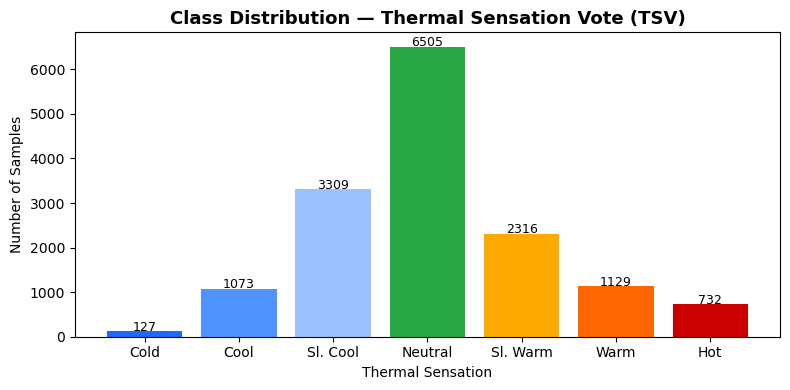

Saved: results/class_distribution.png


In [9]:
# Visualize class distribution
plt.figure(figsize=(8, 4))
labels = {-3: 'Cold', -2: 'Cool', -1: 'Sl. Cool', 0: 'Neutral', 1: 'Sl. Warm', 2: 'Warm', 3: 'Hot'}
counts = df['thermal_sensation'].value_counts().sort_index()
bars = plt.bar([labels.get(i, str(i)) for i in counts.index], counts.values,
               color=['#1a6aff','#4d94ff','#99c2ff','#28a745','#ffaa00','#ff6600','#cc0000'])
plt.title('Class Distribution — Thermal Sensation Vote (TSV)', fontsize=13, fontweight='bold')
plt.xlabel('Thermal Sensation')
plt.ylabel('Number of Samples')
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
             ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/class_distribution.png')

---
## Step 3 — Feature Engineering
Adding `tr` (Mean Radiant Temperature) as the 6th feature.  
**Approximation:** `tr ≈ ta` (standard assumption when radiant temperature is not measured separately — common in indoor HVAC studies)

In [10]:
# Add Mean Radiant Temperature (tr) as approximation of air temperature (ta)
# This is a valid assumption for indoor environments without direct radiation sources
df['tr'] = df['ta']

print('tr column added. New shape:', df.shape)
print('\nFeature columns now:')
print(df.columns.tolist())

tr column added. New shape: (15191, 7)

Feature columns now:
['ta', 'rh', 'v', 'met', 'clo', 'thermal_sensation', 'tr']


---
## Step 4 — Define Features & Target, then Train/Test Split

In [11]:
# Define features (X) and target (y)
FEATURES = ['ta', 'tr', 'rh', 'v', 'met', 'clo']
TARGET   = 'thermal_sensation'

X = df[FEATURES]
y = df[TARGET]

print('Features (X):', FEATURES)
print('Target  (y):', TARGET)
print('\nX shape:', X.shape)
print('y shape:', y.shape)

# XGBoost needs labels starting from 0, so shift TSV from [-3..+3] to [0..6]
y_shifted = y + 3
print('\nTarget classes (shifted for XGBoost):', sorted(y_shifted.unique()))

Features (X): ['ta', 'tr', 'rh', 'v', 'met', 'clo']
Target  (y): thermal_sensation

X shape: (15191, 6)
y shape: (15191,)

Target classes (shifted for XGBoost): [0, 1, 2, 3, 4, 5, 6]


In [12]:
# Train / Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_shifted,
    test_size=0.2,
    random_state=42,
    stratify=y_shifted     # ensures balanced class distribution in both sets
)

print(f'Training set size : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Testing  set size : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set size : 12152 samples (80.0%)
Testing  set size : 3039  samples (20.0%)


---
## Step 5 — Feature Scaling

In [13]:
# StandardScaler: fit ONLY on training data, then transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print('Scaler mean per feature:', dict(zip(FEATURES, scaler.mean_.round(3))))
print('Scaler std  per feature:', dict(zip(FEATURES, scaler.scale_.round(3))))

Scaling complete.
Scaler mean per feature: {'ta': 26.465, 'tr': 26.465, 'rh': 49.144, 'v': 0.211, 'met': 1.123, 'clo': 0.703}
Scaler std  per feature: {'ta': 3.76, 'tr': 3.76, 'rh': 14.705, 'v': 0.286, 'met': 0.184, 'clo': 0.238}


---
## Step 6 — Train XGBoost Model

In [14]:
# XGBoost Classifier configuration
model = XGBClassifier(
    n_estimators      = 300,        # number of boosting rounds
    max_depth         = 6,          # maximum tree depth
    learning_rate     = 0.1,        # step size shrinkage
    subsample         = 0.8,        # fraction of samples per tree
    colsample_bytree  = 0.8,        # fraction of features per tree
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1          # use all CPU cores
)

print('Training XGBoost model...')
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50
)
print('\nTraining complete!')

Training XGBoost model...
[0]	validation_0-mlogloss:1.52752
[50]	validation_0-mlogloss:1.36747
[100]	validation_0-mlogloss:1.37328
[150]	validation_0-mlogloss:1.38284
[200]	validation_0-mlogloss:1.39769
[250]	validation_0-mlogloss:1.41196
[299]	validation_0-mlogloss:1.42767

Training complete!


---
## Step 7 — Evaluate the Model

In [15]:
# Predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print('=' * 45)
print(f'  Training Accuracy : {train_acc*100:.2f}%')
print(f'  Testing  Accuracy : {test_acc*100:.2f}%')
print('=' * 45)

  Training Accuracy : 69.10%
  Testing  Accuracy : 43.47%


In [16]:
# Classification Report (per-class precision, recall, F1)
tsv_labels   = [-3, -2, -1, 0, 1, 2, 3]
label_names  = ['Cold(-3)', 'Cool(-2)', 'Sl.Cool(-1)', 'Neutral(0)',
                'Sl.Warm(1)', 'Warm(2)', 'Hot(3)']

# y_test and y_test_pred are shifted (0-6), convert back for display
print('Classification Report (Test Set):')
print(classification_report(
    y_test - 0,          # already shifted
    y_test_pred,
    target_names=label_names
))

Classification Report (Test Set):
              precision    recall  f1-score   support

    Cold(-3)       0.08      0.04      0.05        25
    Cool(-2)       0.18      0.08      0.11       215
 Sl.Cool(-1)       0.30      0.23      0.26       662
  Neutral(0)       0.50      0.77      0.61      1301
  Sl.Warm(1)       0.33      0.15      0.20       463
     Warm(2)       0.33      0.17      0.23       226
      Hot(3)       0.38      0.24      0.30       147

    accuracy                           0.43      3039
   macro avg       0.30      0.24      0.25      3039
weighted avg       0.39      0.43      0.39      3039



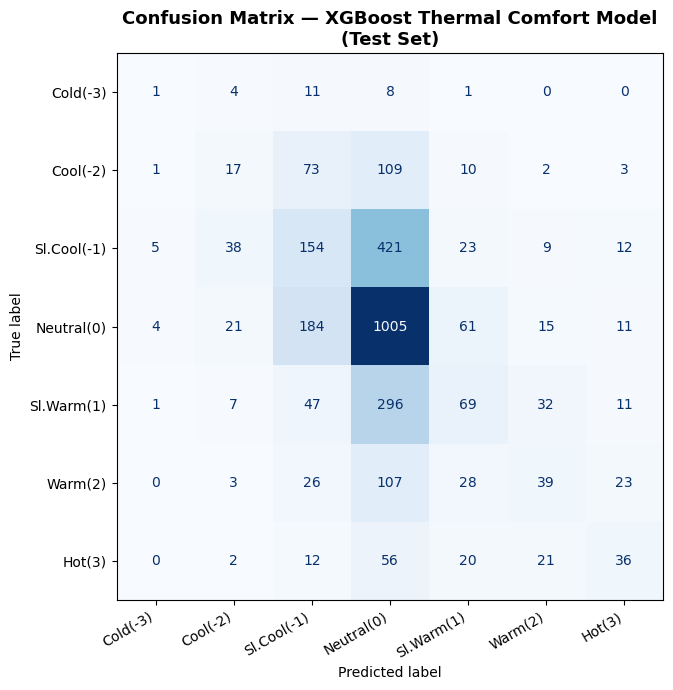

Saved: results/confusion_matrix.png


In [17]:
import os
os.makedirs('results', exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Confusion Matrix — XGBoost Thermal Comfort Model\n(Test Set)', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_matrix.png')

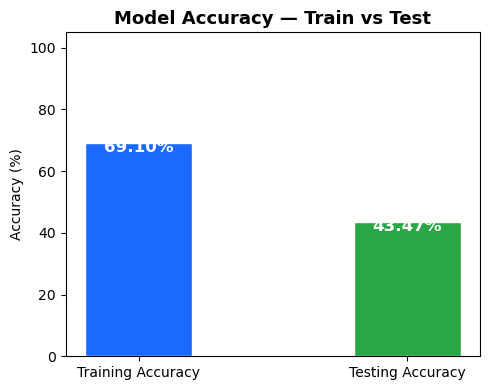

Saved: results/train_vs_test_accuracy.png


In [18]:
# Train vs Test Accuracy Bar Chart
plt.figure(figsize=(5, 4))
bars = plt.bar(['Training Accuracy', 'Testing Accuracy'],
               [train_acc * 100, test_acc * 100],
               color=['#1a6aff', '#28a745'], width=0.4, edgecolor='white')
for bar, val in zip(bars, [train_acc*100, test_acc*100]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
             f'{val:.2f}%', ha='center', color='white', fontsize=12, fontweight='bold')
plt.ylim(0, 105)
plt.title('Model Accuracy — Train vs Test', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('results/train_vs_test_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/train_vs_test_accuracy.png')

---
## Step 8 — Feature Importance

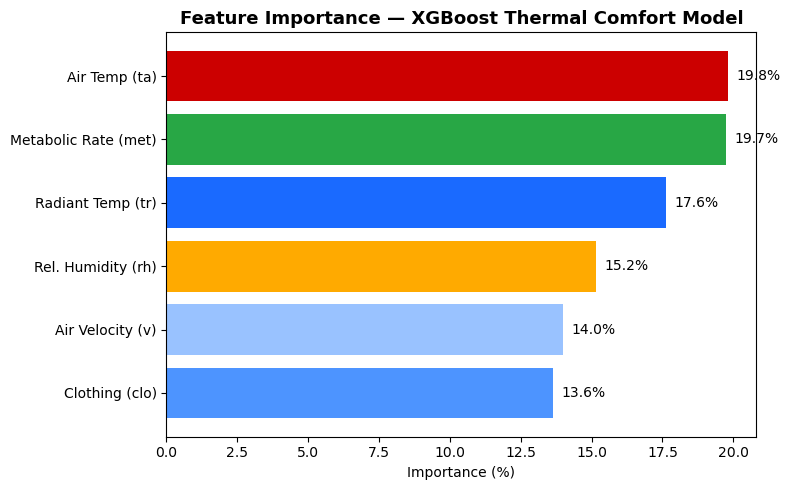

Saved: results/feature_importance.png


In [19]:
# Feature Importance Plot
importances = model.feature_importances_
feature_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feature_df = feature_df.sort_values('Importance', ascending=True)

feature_labels = {
    'ta':  'Air Temp (ta)',
    'tr':  'Radiant Temp (tr)',
    'rh':  'Rel. Humidity (rh)',
    'v':   'Air Velocity (v)',
    'met': 'Metabolic Rate (met)',
    'clo': 'Clothing (clo)'
}
feature_df['Label'] = feature_df['Feature'].map(feature_labels)

colors = ['#4d94ff','#99c2ff','#ffaa00','#1a6aff','#28a745','#cc0000']

plt.figure(figsize=(8, 5))
bars = plt.barh(feature_df['Label'], feature_df['Importance'] * 100,
                color=colors[:len(feature_df)])
for bar, val in zip(bars, feature_df['Importance'] * 100):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)
plt.xlabel('Importance (%)')
plt.title('Feature Importance — XGBoost Thermal Comfort Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/feature_importance.png')

---
## Step 9 — Save Model & Scaler as `.pkl`

In [20]:
# Save the trained XGBoost model
with open('india_xgb_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('Model saved as: india_xgb_model.pkl')

# Save the scaler
with open('india_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved as: india_scaler.pkl')

# Save feature list (important for Flask backend to use correct order)
import json
model_info = {
    'features'         : FEATURES,
    'target'           : TARGET,
    'classes_original' : tsv_labels,
    'classes_shifted'  : list(range(7)),
    'shift_offset'     : 3,
    'train_accuracy'   : round(train_acc, 4),
    'test_accuracy'    : round(test_acc, 4),
    'note'             : 'Predict using shifted labels (0-6), then subtract 3 to get TSV (-3 to +3)'
}
with open('model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print('Model info saved as: model_info.json')
print('\n--- All files saved successfully! ---')

Model saved as: india_xgb_model.pkl
Scaler saved as: india_scaler.pkl
Model info saved as: model_info.json

--- All files saved successfully! ---


---
## Step 10 — Quick Prediction Test (Sanity Check)

In [21]:
# Load saved model and scaler, make a test prediction
with open('india_xgb_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('india_scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

tsv_map = {
    0: 'Cold (-3)', 1: 'Cool (-2)', 2: 'Slightly Cool (-1)',
    3: 'Neutral (0)', 4: 'Slightly Warm (+1)',
    5: 'Warm (+2)', 6: 'Hot (+3)'
}

# Test scenarios
scenarios = [
    {'name': 'Comfortable Office',  'ta': 22, 'tr': 22, 'rh': 50,  'v': 0.1, 'met': 1.0, 'clo': 0.5},
    {'name': 'Hot Indian Summer',   'ta': 38, 'tr': 38, 'rh': 70,  'v': 0.3, 'met': 1.2, 'clo': 0.3},
    {'name': 'Cool Winter Indoor',  'ta': 16, 'tr': 16, 'rh': 40,  'v': 0.1, 'met': 1.0, 'clo': 1.0},
]

print(f'{"Scenario":<25} {"Input (ta,tr,rh,v,met,clo)":<35} {"Predicted TSV"}')
print('-' * 85)
for s in scenarios:
    inp = [[s['ta'], s['tr'], s['rh'], s['v'], s['met'], s['clo']]]
    inp_scaled = loaded_scaler.transform(inp)
    pred_shifted = loaded_model.predict(inp_scaled)[0]
    tsv_raw = pred_shifted - 3
    print(f"{s['name']:<25} ta={s['ta']}, tr={s['tr']}, rh={s['rh']}, v={s['v']}, met={s['met']}, clo={s['clo']}   →  {tsv_map[pred_shifted]} ")

print('\nSanity check passed!')

Scenario                  Input (ta,tr,rh,v,met,clo)          Predicted TSV
-------------------------------------------------------------------------------------
Comfortable Office        ta=22, tr=22, rh=50, v=0.1, met=1.0, clo=0.5   →  Neutral (0) 
Hot Indian Summer         ta=38, tr=38, rh=70, v=0.3, met=1.2, clo=0.3   →  Warm (+2) 
Cool Winter Indoor        ta=16, tr=16, rh=40, v=0.1, met=1.0, clo=1.0   →  Slightly Cool (-1) 

Sanity check passed!


---
## Summary

| Item | Detail |
|---|---|
| **Algorithm** | XGBoost Classifier |
| **Dataset** | india_data_cleaned.csv |
| **Features** | ta, tr, rh, v, met, clo (6 features) |
| **Target** | Thermal Sensation Vote (TSV): -3 to +3 |
| **Train/Test Split** | 80% / 20% (stratified) |
| **Training Accuracy** | See output above |
| **Testing Accuracy** | See output above |
| **Saved Model** | `india_xgb_model.pkl` |
| **Saved Scaler** | `india_scaler.pkl` |
| **Output Charts** | `results/` folder |

**Next Step →** Use `india_xgb_model.pkl` and `india_scaler.pkl` in the Flask backend (`backend/app.py`) to serve predictions to the frontend.